# COMP9517 Lab 3 — Chinese MNIST Classification - Z5658283

## Aim of the Lab
The goal of this lab is to implement and compare the performance of three machine learning classifiers on the Chinese MNIST dataset:

- **K-Nearest Neighbours (KNN)**
- **Decision Tree (DT)**
- **Stochastic Gradient Descent (SGD)**

This lab follows the required workflow:
1. Import relevant packages.
2. Read and inspect the dataset.
3. Perform stratified sampling to create training and testing sets.
4. Reshape image data into a format suitable for machine learning.
5. Initialise the classifiers with the required parameters.
6. Train each classifier using the training set.
7. Use the trained models to make predictions on the test set.
8. Evaluate and compare the performance using standard classification metrics.

## Dataset
The dataset used in this lab is the **Chinese MNIST** dataset.  
Each image is a grayscale handwritten Chinese numeral image of size **64 × 64 pixels**.

## Experiments
Two experiments are conducted in this notebook:

- **Experiment 1:** 5000 training images and 1000 testing images
- **Experiment 2:** 10000 training images and 1000 testing images

The purpose of the second experiment is to examine whether increasing the number of training samples improves classification performance.

## Step 1 — Import Relevant Packages

In this step, the necessary Python libraries are imported.

### Main libraries used
- **os**: used for file path construction and file checking
- **cv2 (OpenCV)**: used for reading image files
- **numpy**: used for numerical arrays and image data storage
- **pandas**: used for reading and managing the CSV file
- **matplotlib**: used for displaying sample images and confusion matrices

### Scikit-Learn modules used
- **train_test_split**: used to split the dataset into training and testing subsets
- **KNeighborsClassifier**: KNN classifier
- **DecisionTreeClassifier**: Decision Tree classifier
- **SGDClassifier**: linear classifier trained with stochastic gradient descent
- **classification metrics**: used to evaluate model performance

Scikit-Learn is the main machine learning library used in this lab, so importing the correct modules is the first step before building and evaluating the classifiers.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Step 2 — Set Dataset Paths

In this step, the file paths of the dataset are defined.

The dataset folder contains:
- the main dataset folder
- the image files
- the CSV file containing labels and metadata
- the TFRecords file

### Important note
In this local dataset, the actual image files are stored inside:

`data/data`

rather than only `data`.

Therefore, the image path must be set carefully to ensure that all images can be read correctly.

### Why this step is important
If the image folder path is incorrect:
- `cv2.imread()` will fail
- no images will be loaded
- later steps such as reshaping and classification will not work

This step also checks whether each required path exists before proceeding.

In [2]:
base_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset"
data_path = os.path.join(base_path, "data", "data")
csv_path = os.path.join(base_path, "chinese_mnist.csv")
tfrecords_path = os.path.join(base_path, "chinese_mnist.tfrecords")

print("base_path:", base_path)
print("data_path:", data_path)
print("csv_path:", csv_path)
print("tfrecords_path:", tfrecords_path)

print()
print("base_path exists:", os.path.exists(base_path))
print("data_path exists:", os.path.exists(data_path))
print("csv_path exists:", os.path.exists(csv_path))
print("tfrecords_path exists:", os.path.exists(tfrecords_path))

base_path: C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset
data_path: C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\data\data
csv_path: C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\chinese_mnist.csv
tfrecords_path: C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\chinese_mnist.tfrecords

base_path exists: True
data_path exists: True
csv_path exists: True
tfrecords_path exists: True


## Step 3 — Read the CSV File

The CSV file contains important information about the dataset, including:
- `suite_id`
- `sample_id`
- `code`
- `value`
- `character`

These fields are used to:
1. understand the dataset structure
2. identify the class label of each image
3. reconstruct the corresponding image filename

### Why this step is necessary
Although the image files contain the handwritten numerals, the labels are not directly stored inside the images.  
Instead, the class information is obtained from the CSV file and from the image filename pattern.

By printing the shape, column names, and first few rows of the CSV file, we can verify that the dataset has been loaded correctly before continuing.

In [3]:
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print(df.head())

Dataset shape: (15000, 5)
Columns: ['suite_id', 'sample_id', 'code', 'value', 'character']

   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九


## Step 4 — Inspect the Dataset

Before training any classifier, it is important to understand the dataset.

In this step, the following basic properties are checked:
- the total number of images
- the size of each image
- the number of classes
- the number of images in each class
- the mapping between class code, numeric value, and Chinese character

### Expected observations
- The dataset contains **15,000 images**
- Each image has size **64 × 64**
- There are **15 classes**
- The classes are approximately balanced

### Why this step matters
Understanding the dataset helps confirm that:
- the data is complete
- the class distribution is reasonable
- there is no obvious class imbalance before sampling

This also provides useful background information for the report and interpretation of later results.

In [4]:
print("Total number of images:", len(df))
print("Image size: 64 x 64")
print("Number of classes:", df["code"].nunique())

print()
print("Images in each class:")
print(df["code"].value_counts().sort_index())

print()
print("Class mapping:")
print(df[["code", "value", "character"]].drop_duplicates().sort_values("code"))

Total number of images: 15000
Image size: 64 x 64
Number of classes: 15

Images in each class:
code
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
10    1000
11    1000
12    1000
13    1000
14    1000
15    1000
Name: count, dtype: int64

Class mapping:
       code      value character
6000      1          0         零
7000      2          1         一
8000      3          2         二
9000      4          3         三
10000     5          4         四
11000     6          5         五
12000     7          6         六
13000     8          7         七
14000     9          8         八
0        10          9         九
1000     11         10         十
2000     12        100         百
3000     13       1000         千
4000     14      10000         万
5000     15  100000000         亿


## Step 5 — Build the Image Path for Each Sample

The Chinese MNIST images follow a filename pattern:

`input_suiteid_sampleid_code.jpg`

The CSV file provides the values needed to reconstruct this filename:
- `suite_id`
- `sample_id`
- `code`

These values are combined with the image folder path to create the full path of each image.

### Why this step is important
Machine learning models cannot work directly from the CSV table alone.  
We still need to locate and load each image file from disk.

### Important implementation detail
The values of `suite_id`, `sample_id`, and `code` are converted to integers before creating the filename.

This avoids accidental filenames such as:
- `input_1.0_1.0_10.0.jpg`

which would not match the real files on disk.

At the end of this step, the full image path of each sample is stored in a new column called `image_path`.

In [5]:
image_paths = []

for i in range(len(df)):
    suite_id = int(df.loc[i, "suite_id"])
    sample_id = int(df.loc[i, "sample_id"])
    code = int(df.loc[i, "code"])

    file_name = "input_" + str(suite_id) + "_" + str(sample_id) + "_" + str(code) + ".jpg"
    full_path = os.path.join(data_path, file_name)
    image_paths.append(full_path)

df["image_path"] = image_paths

print(df[["suite_id", "sample_id", "code", "image_path"]].head())

print()
for i in range(5):
    print(df.loc[i, "image_path"])
    print("exists:", os.path.exists(df.loc[i, "image_path"]))
    print()

   suite_id  sample_id  code  \
0         1          1    10   
1         1         10    10   
2         1          2    10   
3         1          3    10   
4         1          4    10   

                                          image_path  
0  C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chines...  
1  C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chines...  
2  C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chines...  
3  C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chines...  
4  C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chines...  

C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\data\data\input_1_1_10.jpg
exists: True

C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\data\data\input_1_10_10.jpg
exists: True

C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\data\data\input_1_2_10.jpg
exists: True

C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\data\data\input_1_3_10.jpg
exists: True

C:\Users\ROG\Desktop\UNSW\COMP9517\lab3\Chinese_MINST_Dataset\d

## Step 6 — Load Images and Labels

In this step, each image is read from its file path using OpenCV in grayscale mode.

### What is done here
- Read each image using `cv2.imread(..., cv2.IMREAD_GRAYSCALE)`
- Store the image in a list
- Store the corresponding class label in another list
- Convert the lists into NumPy arrays
- Normalise pixel values from the original range `[0, 255]` to `[0, 1]`

### Why grayscale is used
The Chinese MNIST images are grayscale images, so only one intensity channel is needed.

### Why normalisation is useful
Normalising the image values helps machine learning algorithms work more stably, especially for models such as SGD.

### Error handling
If an image cannot be read, its path is stored in `bad_paths`.  
This allows us to detect path problems early instead of silently failing.

At the end of this step:
- `X` contains the image data
- `y` contains the labels

In [6]:
images = []
labels = []
bad_paths = []

for i in range(len(df)):
    img_path = df.loc[i, "image_path"]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        bad_paths.append(img_path)
    else:
        images.append(img)
        labels.append(int(df.loc[i, "code"]))

print("Successfully loaded images:", len(images))
print("Failed images:", len(bad_paths))

X = np.array(images, dtype=np.float32)
y = np.array(labels)

if len(X) > 0:
    X = X / 255.0
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("One image shape:", X[0].shape)
    print("Pixel min:", X.min())
    print("Pixel max:", X.max())
else:
    print("No images were loaded.")

Successfully loaded images: 15000
Failed images: 0
X shape: (15000, 64, 64)
y shape: (15000,)
One image shape: (64, 64)
Pixel min: 0.0
Pixel max: 1.0


## Step 7 — Visualise Sample Images

In this step, one example image from each class is displayed.

### Purpose
This visual inspection helps us:
- verify that the images were loaded correctly
- confirm that different classes correspond to different handwritten Chinese numerals
- better understand the appearance and variability of the dataset

### Why this is useful
Looking at sample images is an important part of familiarising ourselves with the dataset.  
It also helps identify possible issues such as:
- unreadable images
- incorrect labels
- wrong grayscale loading
- unexpected image orientation or formatting

This step satisfies the requirement to inspect some images from each label before beginning classification.

C:\Users\ROG\AppData\Local\Temp\ipykernel_6388\2769456428.py:16: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_6388\2769456428.py:16: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_6388\2769456428.py:16: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_6388\2769456428.py:16: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_6388\2769456428.py:16: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_6388\2769456428.py:16: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEO

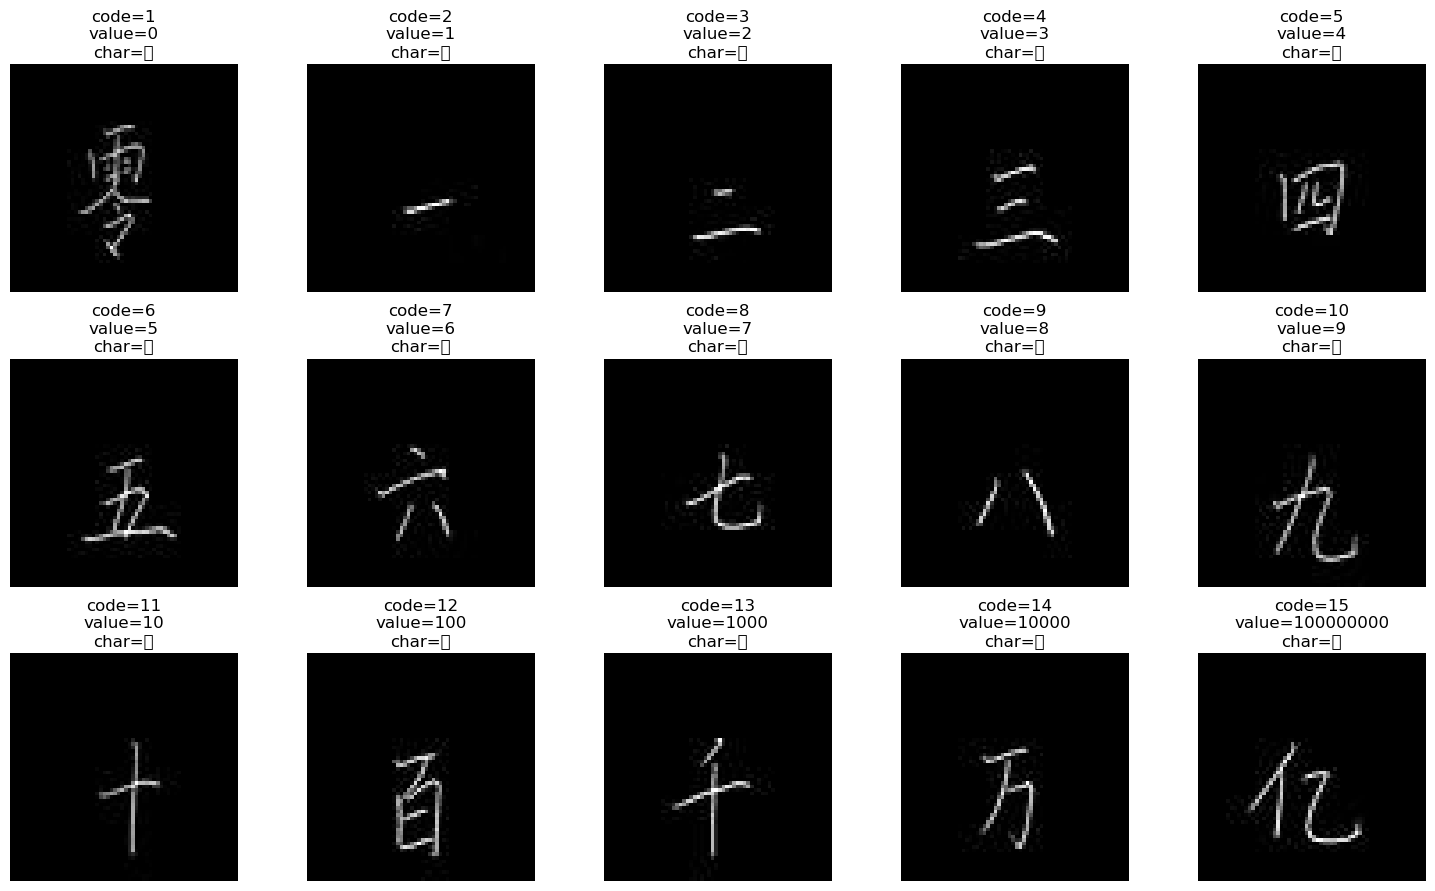

In [7]:
unique_codes = sorted(df["code"].unique())

plt.figure(figsize=(15, 9))

for i in range(len(unique_codes)):
    code_value = unique_codes[i]
    first_index = df[df["code"] == code_value].index[0]

    plt.subplot(3, 5, i + 1)
    plt.imshow(X[first_index], cmap="gray")
    plt.title("code=" + str(df.loc[first_index, "code"]) +
              "\nvalue=" + str(df.loc[first_index, "value"]) +
              "\nchar=" + str(df.loc[first_index, "character"]))
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 8 — Stratified Split of the Dataset

The lab requires randomly sampled subsets of the full dataset:
- **5000 images for training**
- **1000 images for testing**

The sampling must be **stratified**, meaning that the class distribution is kept approximately balanced across the subsets.

### Why stratified sampling is used
If the sampling is not stratified, some classes may appear much more often than others in the training or testing set.  
This can create class imbalance and lead to misleading evaluation results.

### Why the training and testing sets must be separate
The testing set must not contain images that were used during training.  
If the same image appears in both training and testing data, this causes **data leakage**.  
Data leakage makes performance look better than it really is because the model has already seen some of the test images.

### In this notebook
A fixed **1000-image test set** is first created using stratified sampling.  
The remaining images are kept in a training pool.  
Later, we will sample:
- 5000 training images from this pool
- 10000 training images from this pool

This ensures that:
- the test set remains fixed
- the test set does not overlap with the training set
- the experiments are fair and comparable

In [8]:
all_indices = np.arange(len(X))

train_pool_idx, test_idx = train_test_split(
    all_indices,
    test_size=1000,
    stratify=y,
    random_state=42
)

print("Train pool size:", len(train_pool_idx))
print("Test size:", len(test_idx))

print()
print("Class counts in test set:")
print(pd.Series(y[test_idx]).value_counts().sort_index())

Train pool size: 14000
Test size: 1000

Class counts in test set:
1     66
2     67
3     67
4     67
5     67
6     66
7     67
8     67
9     67
10    66
11    67
12    66
13    67
14    66
15    67
Name: count, dtype: int64


## Step 9 — Reshape the Image Data

Machine learning classifiers in Scikit-Learn expect the input data to be arranged as a 2D matrix:

- one row = one sample
- one column = one feature

However, each Chinese MNIST image is currently stored as a **64 × 64** 2D array.

### Therefore
Each image must be reshaped into a 1D feature vector of length:

`64 × 64 = 4096`

After reshaping:
- original shape: `(number_of_images, 64, 64)`
- new shape: `(number_of_images, 4096)`

### Why this step is required
KNN, Decision Tree, and SGD in Scikit-Learn do not directly take 2D image matrices as input.  
They require each image to be flattened into a single feature vector.

This step prepares the image data in the correct format for model training and testing.

In [9]:
X_flat = X.reshape(X.shape[0], 64 * 64)

print("Original X shape:", X.shape)
print("Flattened X shape:", X_flat.shape)

Original X shape: (15000, 64, 64)
Flattened X shape: (15000, 4096)


## Step 10 — Helper Functions

To keep the notebook organised and readable, helper functions are defined.

### Function 1: `get_train_indices()`
This function creates a stratified training subset from the training pool.

It is used to create:
- the 5000-image training set
- the 10000-image training set

### Why this function is useful
It avoids rewriting the same sampling logic multiple times and ensures that stratified sampling is applied consistently.

### Function 2: `evaluate_model()`
This function performs the full evaluation process for one classifier:
1. fit the model on the training data
2. predict labels for the test data
3. compute performance metrics
4. print the classification report
5. generate the confusion matrix plot
6. save the summary results in a dictionary

### Why this function is useful
All three classifiers should be evaluated in the same way.  
Using one shared function ensures consistency and makes model comparison easier and fairer.

In [10]:
def get_train_indices(pool_indices, labels, train_size, random_state=42):
    pool_labels = labels[pool_indices]

    selected_train_idx, _ = train_test_split(
        pool_indices,
        train_size=train_size,
        stratify=pool_labels,
        random_state=random_state
    )

    return selected_train_idx

In [11]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, train_size):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("=" * 70)
    print("Model:", model_name)
    print("Training size:", train_size)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print()
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(model_name + " - train size " + str(train_size))
    plt.show()

    result = {
        "model": model_name,
        "train_size": train_size,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }

    return result

## Step 11 — Create the 5000-Image Training Set

This is the first required experiment.

A stratified sample of **5000 images** is taken from the training pool created earlier.  
The testing set remains fixed at **1000 images**.

### Why this step is important
This step follows the lab requirement to start with a reduced subset of the dataset in order to lower computational cost while still keeping the experiment meaningful.

### Expected class balance
Since there are 15 classes, the training set should contain approximately:

- `5000 / 15 ≈ 333` images per class

The exact counts may not be perfectly equal, but they should be very close because stratified sampling is used.

This training set is used in the first round of classifier training and evaluation.

In [12]:
train_5000_idx = get_train_indices(train_pool_idx, y, 5000, random_state=42)

X_train_5000 = X_flat[train_5000_idx]
y_train_5000 = y[train_5000_idx]

X_test = X_flat[test_idx]
y_test = y[test_idx]

print("X_train_5000 shape:", X_train_5000.shape)
print("y_train_5000 shape:", y_train_5000.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print()
print("Class counts in 5000 training set:")
print(pd.Series(y_train_5000).value_counts().sort_index())

X_train_5000 shape: (5000, 4096)
y_train_5000 shape: (5000,)
X_test shape: (1000, 4096)
y_test shape: (1000,)

Class counts in 5000 training set:
1     334
2     333
3     333
4     333
5     333
6     334
7     333
8     333
9     333
10    334
11    333
12    334
13    333
14    334
15    333
Name: count, dtype: int64


## Step 12 — Prepare a Results Container

An empty list called `results` is created to store the evaluation results of each classifier.

For each experiment, the following information will be saved:
- model name
- training size
- accuracy
- precision
- recall
- F1-score

### Why this is useful
Keeping the results in a list and later converting them to a DataFrame makes it easier to:
- compare the models
- compare different training sizes
- identify the best-performing classifier
- present the final results clearly

In [13]:
results = []

## Step 13 — K-Nearest Neighbours (KNN)

KNN is a simple instance-based classifier.  
It classifies a test sample by looking at the labels of the nearest training samples in feature space.

### Parameter setting
According to the lab requirement:
- `k = 3`

This means the classifier uses the **3 nearest neighbours** to decide the predicted class.

### How KNN works in this lab
Each flattened image is treated as a point in a 4096-dimensional feature space.  
For a new test image, KNN finds the 3 closest training images and predicts the class based on majority voting.

### Why KNN is useful here
KNN is straightforward and often works reasonably well for image classification when similar images have similar pixel patterns.

After training, the model is evaluated on the fixed 1000-image test set.

Model: KNN
Training size: 5000
Accuracy: 0.351
Precision: 0.5630910688958937
Recall: 0.350444745967134
F1-score: 0.3582437396455548

Classification report:
              precision    recall  f1-score   support

           1       0.89      0.61      0.72        66
           2       0.15      0.97      0.26        67
           3       0.21      0.34      0.26        67
           4       0.30      0.30      0.30        67
           5       0.61      0.21      0.31        67
           6       0.55      0.09      0.16        66
           7       0.28      0.22      0.25        67
           8       0.57      0.24      0.34        67
           9       0.95      0.85      0.90        67
          10       0.60      0.14      0.22        66
          11       0.44      0.51      0.47        67
          12       0.86      0.18      0.30        66
          13       0.60      0.27      0.37        67
          14       0.44      0.18      0.26        66
          15       1.00      0.15

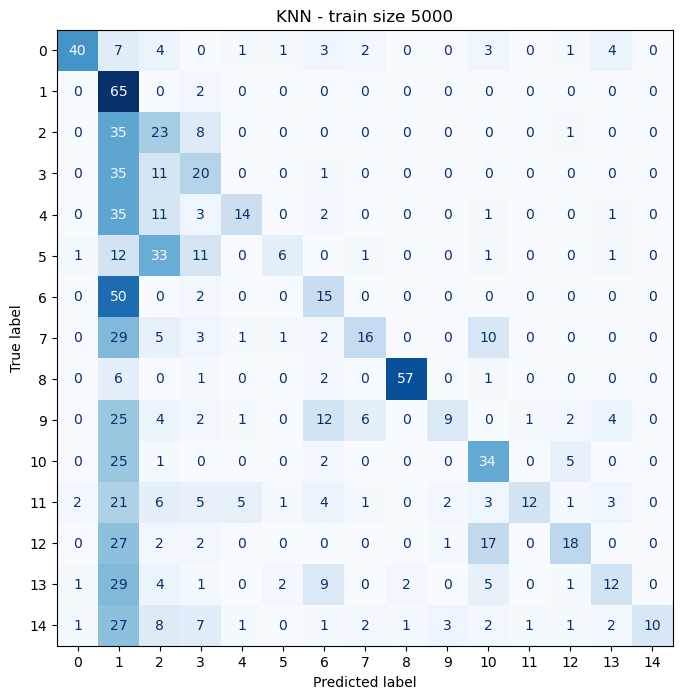

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=3)

result_knn_5000 = evaluate_model(
    knn_model,
    "KNN",
    X_train_5000,
    y_train_5000,
    X_test,
    y_test,
    5000
)

results.append(result_knn_5000)

## Step 14 — Decision Tree (DT)

A Decision Tree classifier learns a sequence of decision rules from the training data.

### Parameter setting
The lab requires the classifier to use:
- **default settings**

Therefore, no special parameters are manually adjusted here.

### How Decision Tree works in this lab
The model examines pixel-based features and learns rules that split the data into smaller subsets.  
The final prediction is made based on the learned tree structure.

### Advantages
- easy to understand conceptually
- can model nonlinear decision boundaries
- does not require feature scaling as strongly as some linear models

### Evaluation
The trained Decision Tree model is tested on the same 1000-image test set so that its performance can be directly compared with KNN and SGD.

Model: Decision Tree
Training size: 5000
Accuracy: 0.282
Precision: 0.27624556196298644
Recall: 0.281592039800995
F1-score: 0.27747789592622635

Classification report:
              precision    recall  f1-score   support

           1       0.42      0.36      0.39        66
           2       0.68      0.78      0.73        67
           3       0.23      0.28      0.25        67
           4       0.21      0.21      0.21        67
           5       0.32      0.28      0.30        67
           6       0.22      0.21      0.21        66
           7       0.18      0.18      0.18        67
           8       0.15      0.16      0.16        67
           9       0.24      0.27      0.26        67
          10       0.10      0.11      0.11        66
          11       0.47      0.57      0.52        67
          12       0.19      0.15      0.17        66
          13       0.29      0.31      0.30        67
          14       0.18      0.17      0.17        66
          15       0.

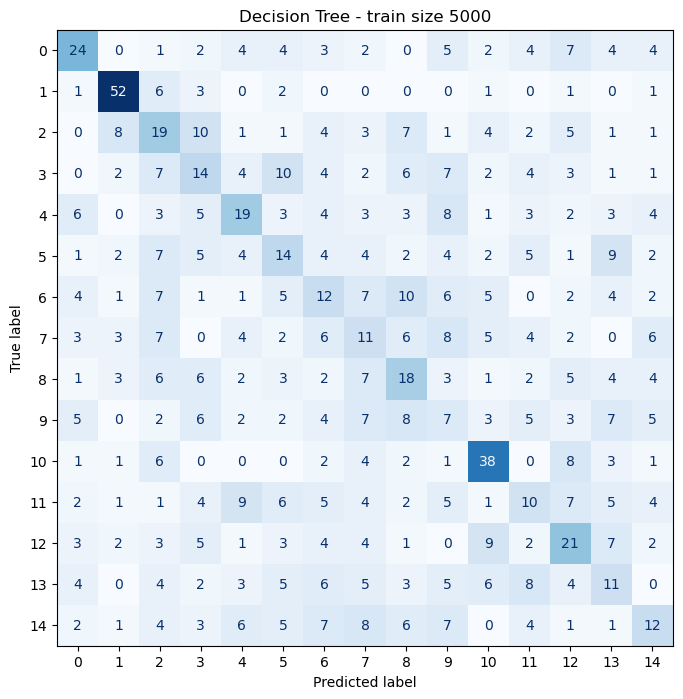

In [15]:
dt_model = DecisionTreeClassifier()

result_dt_5000 = evaluate_model(
    dt_model,
    "Decision Tree",
    X_train_5000,
    y_train_5000,
    X_test,
    y_test,
    5000
)

results.append(result_dt_5000)

## Step 15 — Stochastic Gradient Descent (SGD)

SGD is an optimisation-based classifier that learns model parameters by updating them iteratively using training data.

### Parameter setting
According to the lab requirement:
- `max_iter = 250`

All other parameters are kept at their default values.

### Why normalisation helps here
SGD often performs better when input features are on a comparable scale.  
That is one reason why the pixel values were normalised earlier.

### How SGD works in this lab
Each flattened image is treated as a feature vector.  
The model learns decision boundaries by iteratively minimising a loss function through gradient-based updates.

### Evaluation
After training, the SGD classifier is tested on the same fixed test set and evaluated using:
- accuracy
- precision
- recall
- F1-score
- confusion matrix

Model: SGD
Training size: 5000
Accuracy: 0.417
Precision: 0.42124287622874235
Recall: 0.4168551183476556
F1-score: 0.4155099197660798

Classification report:
              precision    recall  f1-score   support

           1       0.76      0.67      0.71        66
           2       0.60      0.78      0.68        67
           3       0.30      0.21      0.25        67
           4       0.30      0.31      0.31        67
           5       0.49      0.49      0.49        67
           6       0.43      0.33      0.38        66
           7       0.32      0.31      0.32        67
           8       0.38      0.40      0.39        67
           9       0.68      0.60      0.63        67
          10       0.25      0.27      0.26        66
          11       0.52      0.49      0.51        67
          12       0.30      0.33      0.32        66
          13       0.38      0.46      0.42        67
          14       0.25      0.33      0.29        66
          15       0.35      0.

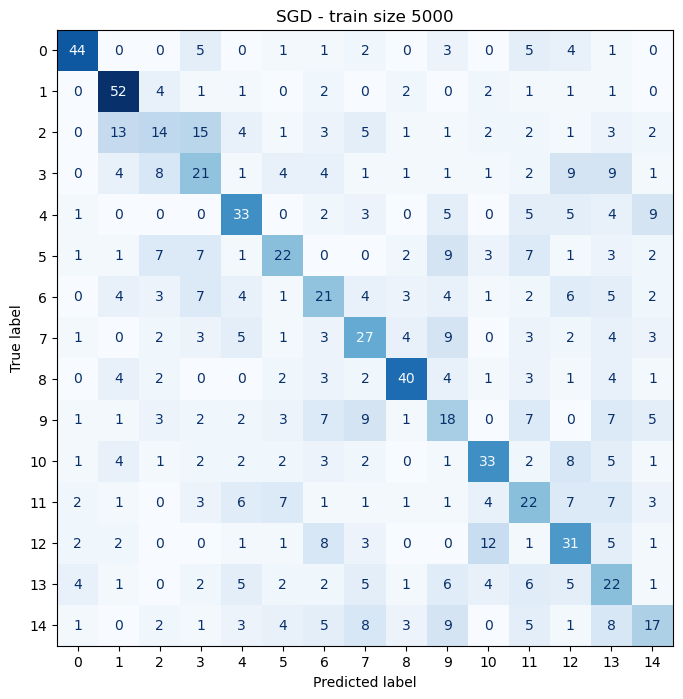

In [16]:
sgd_model = SGDClassifier(max_iter=250)

result_sgd_5000 = evaluate_model(
    sgd_model,
    "SGD",
    X_train_5000,
    y_train_5000,
    X_test,
    y_test,
    5000
)

results.append(result_sgd_5000)

## Step 16 — Create the 10000-Image Training Set

After completing the first experiment, the lab requires the number of training images to be doubled from **5000** to **10000**.

The test set remains fixed at **1000 images**.

### Why this second experiment is needed
The purpose is to examine whether increasing the size of the training set improves classification performance.

In general, more training data may help the classifier learn a better representation of each class.  
However, the extent of the improvement may differ across models.

### Expected class balance
Since there are 15 classes, the 10000-image training set should contain approximately:

- `10000 / 15 ≈ 666` images per class

Again, the counts should be close because stratified sampling is used.

In [17]:
train_10000_idx = get_train_indices(train_pool_idx, y, 10000, random_state=42)

X_train_10000 = X_flat[train_10000_idx]
y_train_10000 = y[train_10000_idx]

print("X_train_10000 shape:", X_train_10000.shape)
print("y_train_10000 shape:", y_train_10000.shape)

print()
print("Class counts in 10000 training set:")
print(pd.Series(y_train_10000).value_counts().sort_index())

X_train_10000 shape: (10000, 4096)
y_train_10000 shape: (10000,)

Class counts in 10000 training set:
1     667
2     667
3     667
4     666
5     666
6     667
7     666
8     667
9     666
10    667
11    667
12    667
13    667
14    667
15    666
Name: count, dtype: int64


## Step 17 — KNN with 10000 Training Images

In this experiment, the KNN classifier is trained again using the larger 10000-image training set.

The value of `k` remains:
- `k = 3`

### Purpose
This allows us to compare:
- KNN performance with 5000 training images
- KNN performance with 10000 training images

### What we want to observe
If the larger training set improves performance, we may expect:
- higher accuracy
- better precision and recall
- fewer classification errors in the confusion matrix

This helps us understand how sensitive KNN is to the amount of training data.

Model: KNN
Training size: 10000
Accuracy: 0.435
Precision: 0.6018963995874775
Recall: 0.4344791195537464
F1-score: 0.4438584654486341

Classification report:
              precision    recall  f1-score   support

           1       0.88      0.67      0.76        66
           2       0.19      0.97      0.32        67
           3       0.27      0.45      0.34        67
           4       0.40      0.43      0.41        67
           5       0.86      0.36      0.51        67
           6       0.62      0.15      0.24        66
           7       0.31      0.25      0.28        67
           8       0.50      0.27      0.35        67
           9       0.89      0.96      0.92        67
          10       0.61      0.21      0.31        66
          11       0.49      0.61      0.55        67
          12       0.89      0.26      0.40        66
          13       0.66      0.31      0.42        67
          14       0.60      0.36      0.45        66
          15       0.85      0.

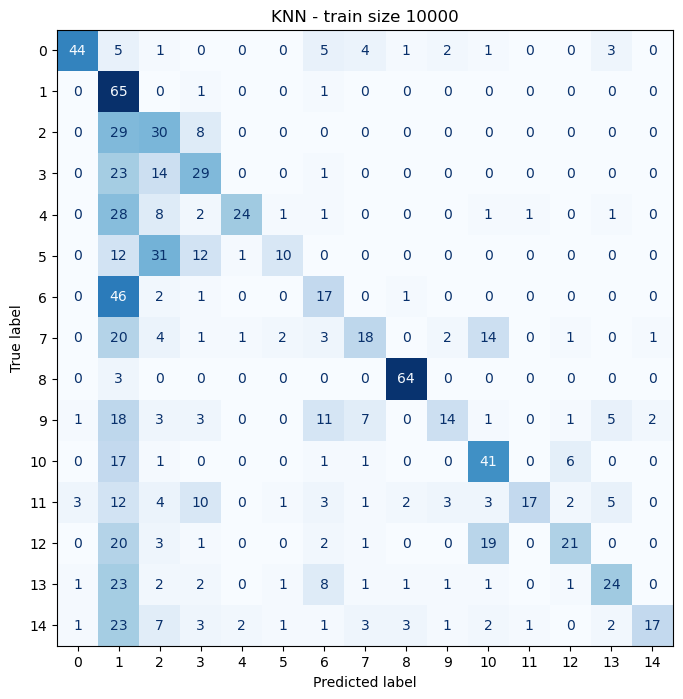

In [18]:
knn_model = KNeighborsClassifier(n_neighbors=3)

result_knn_10000 = evaluate_model(
    knn_model,
    "KNN",
    X_train_10000,
    y_train_10000,
    X_test,
    y_test,
    10000
)

results.append(result_knn_10000)

## Step 18 — Decision Tree with 10000 Training Images

The Decision Tree classifier is retrained using the larger 10000-image training set.

### Purpose
The goal is to determine whether the Decision Tree benefits from additional training data.

### Comparison focus
Later, we will compare:
- Decision Tree with 5000 training images
- Decision Tree with 10000 training images
- Decision Tree versus the other classifiers

This comparison helps us evaluate both:
- the effect of training set size
- the relative performance of the different classification methods

Model: Decision Tree
Training size: 10000
Accuracy: 0.301
Precision: 0.29766532109905147
Recall: 0.3007085783205186
F1-score: 0.2982719686322207

Classification report:
              precision    recall  f1-score   support

           1       0.47      0.42      0.45        66
           2       0.65      0.76      0.70        67
           3       0.39      0.39      0.39        67
           4       0.31      0.25      0.28        67
           5       0.23      0.24      0.23        67
           6       0.22      0.21      0.21        66
           7       0.26      0.24      0.25        67
           8       0.18      0.19      0.19        67
           9       0.39      0.45      0.42        67
          10       0.25      0.24      0.24        66
          11       0.29      0.30      0.30        67
          12       0.24      0.24      0.24        66
          13       0.23      0.25      0.24        67
          14       0.09      0.09      0.09        66
          15       0

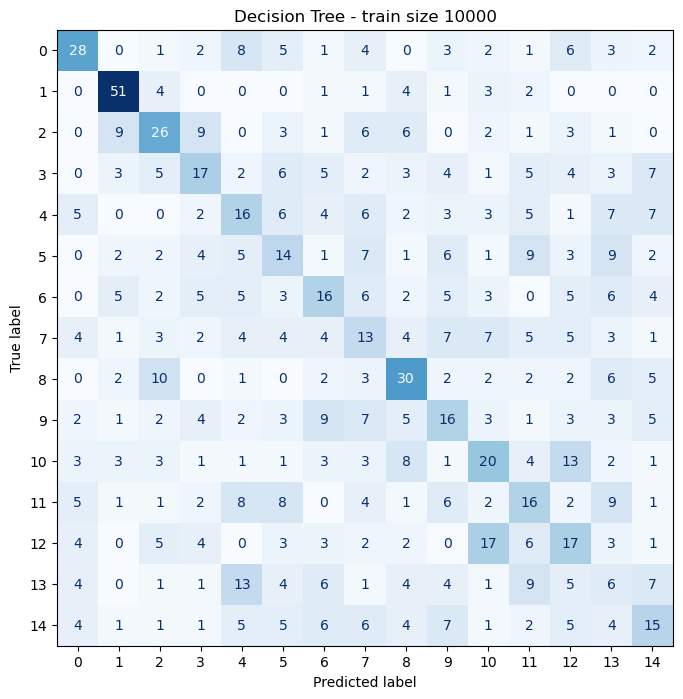

In [19]:
dt_model = DecisionTreeClassifier()

result_dt_10000 = evaluate_model(
    dt_model,
    "Decision Tree",
    X_train_10000,
    y_train_10000,
    X_test,
    y_test,
    10000
)

results.append(result_dt_10000)

## Step 19 — SGD with 10000 Training Images

The SGD classifier is also retrained using the 10000-image training set.

The required setting is still:
- `max_iter = 250`

### Purpose
This second SGD experiment helps us determine whether more training data improves the performance of this classifier.

### Why this comparison is important
Different classifiers respond differently to larger training sets.  
For example:
- some models may improve significantly
- some may improve only slightly
- some may remain unstable for certain classes

The evaluation metrics and confusion matrix will help us analyse the change in performance.

Model: SGD
Training size: 10000
Accuracy: 0.442
Precision: 0.43933405170342904
Recall: 0.4417458163726821
F1-score: 0.4284360364963778

Classification report:
              precision    recall  f1-score   support

           1       0.66      0.76      0.70        66
           2       0.54      0.90      0.67        67
           3       0.39      0.28      0.33        67
           4       0.37      0.46      0.41        67
           5       0.56      0.55      0.56        67
           6       0.41      0.50      0.45        66
           7       0.46      0.28      0.35        67
           8       0.30      0.40      0.34        67
           9       0.64      0.63      0.63        67
          10       0.24      0.24      0.24        66
          11       0.38      0.57      0.46        67
          12       0.33      0.20      0.25        66
          13       0.41      0.28      0.34        67
          14       0.41      0.26      0.32        66
          15       0.49      0

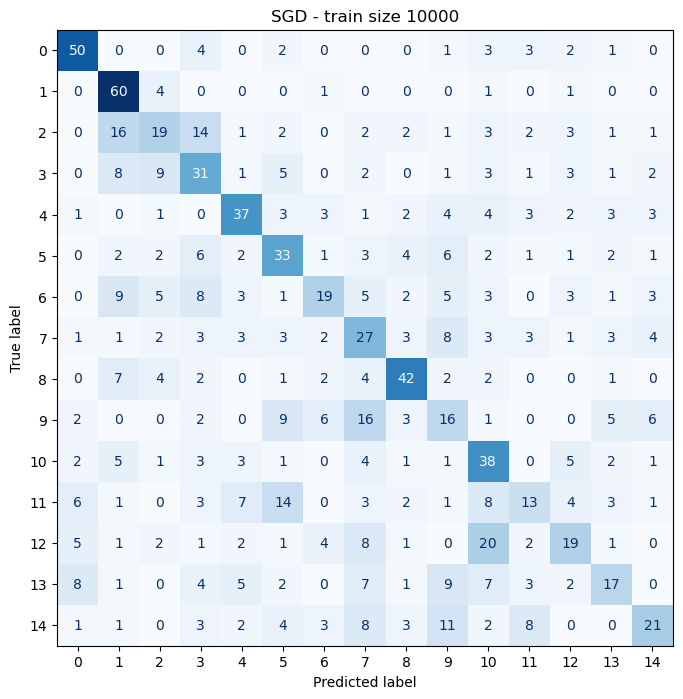

In [20]:
sgd_model = SGDClassifier(max_iter=250)

result_sgd_10000 = evaluate_model(
    sgd_model,
    "SGD",
    X_train_10000,
    y_train_10000,
    X_test,
    y_test,
    10000
)

results.append(result_sgd_10000)

## Step 20 — Final Results Table

After all experiments are completed, the performance results are collected into a single table.

### What the table contains
For each classifier and each training size, the table reports:
- model name
- training size
- accuracy
- precision
- recall
- F1-score

### Why this table is useful
This gives a compact summary of the entire lab experiment and makes it easier to:
- compare classifiers
- compare training sizes
- identify the best-performing model

In [21]:
results_df = pd.DataFrame(results)

print(results_df)

           model  train_size  accuracy  precision    recall  f1_score
0            KNN        5000     0.351   0.563091  0.350445  0.358244
1  Decision Tree        5000     0.282   0.276246  0.281592  0.277478
2            SGD        5000     0.417   0.421243  0.416855  0.415510
3            KNN       10000     0.435   0.601896  0.434479  0.443858
4  Decision Tree       10000     0.301   0.297665  0.300709  0.298272
5            SGD       10000     0.442   0.439334  0.441746  0.428436


## Step 21 — Sort Results by Accuracy

To make model comparison clearer, the final results table is sorted by accuracy in descending order.

### Why sorting is helpful
This allows us to quickly identify:
- which classifier achieved the highest accuracy
- whether increasing the training size improved the result
- which model performed worst overall

Although accuracy is not the only important metric, it is often the first measure used for an overall comparison.

In [22]:
results_df = results_df.sort_values(by="accuracy", ascending=False)

print(results_df)

           model  train_size  accuracy  precision    recall  f1_score
5            SGD       10000     0.442   0.439334  0.441746  0.428436
3            KNN       10000     0.435   0.601896  0.434479  0.443858
2            SGD        5000     0.417   0.421243  0.416855  0.415510
0            KNN        5000     0.351   0.563091  0.350445  0.358244
4  Decision Tree       10000     0.301   0.297665  0.300709  0.298272
1  Decision Tree        5000     0.282   0.276246  0.281592  0.277478


## Step 22 — Visual Comparison Using a Bar Chart

A bar chart is used to visually compare the accuracy of all classifier and training-size combinations.

### Why this plot is helpful
Numerical tables are precise, but a graph makes the overall comparison easier to see at a glance.

From this chart, we can quickly observe:
- which experiment produced the highest accuracy
- whether larger training data improved performance
- how the three classifiers compare visually

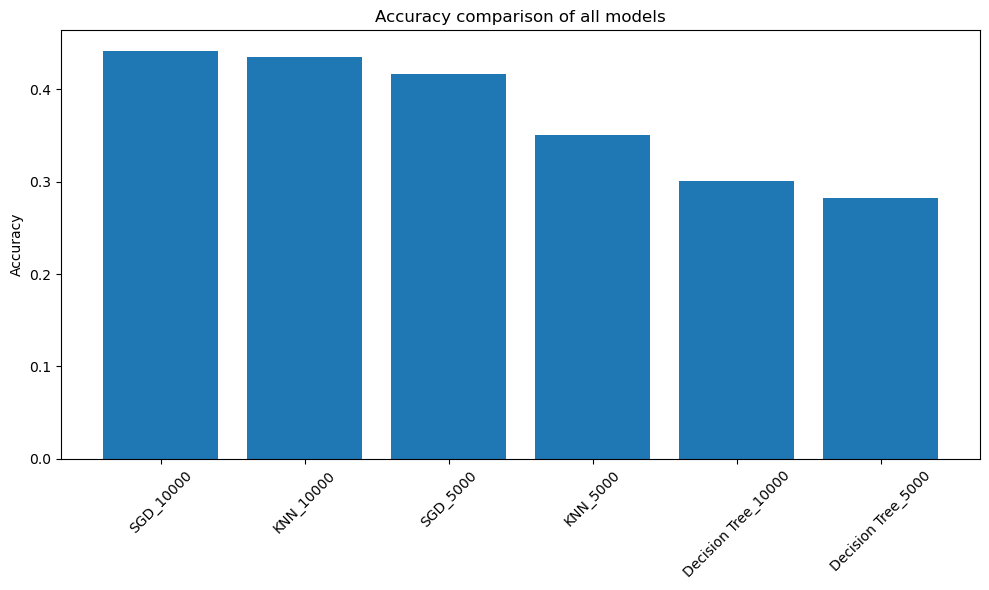

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["model"] + "_" + results_df["train_size"].astype(str), results_df["accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Accuracy comparison of all models")
plt.tight_layout()
plt.show()

## Step 23 — Conclusion

This notebook implemented and compared three classifiers on the Chinese MNIST dataset:
- KNN
- Decision Tree
- SGD

Two experiments were carried out:
- 5000 training images + 1000 testing images
- 10000 training images + 1000 testing images

All experiments used:
- stratified sampling
- separate training and testing sets
- reshaped image vectors
- standard classification metrics

The final comparison is based on:
- accuracy
- precision
- recall
- F1-score
- confusion matrix

From the results, we can determine:
1. which classifier performed best overall
2. whether increasing the number of training images improved performance
3. how classification errors were distributed across the 15 classes